In [1]:
# -------------------------------------------------------
# Block 1: 光谱网格 + 刺激生成（Clean Build）
# -------------------------------------------------------

import numpy as np

# 光谱范围（nm）
wl_min, wl_max, wl_step = 380, 700, 5
wavelengths = np.arange(wl_min, wl_max + wl_step, wl_step)
n_wl = len(wavelengths)

# 生成高斯窄带光谱
def make_narrow_spectrum(center_nm, width_nm=20.0, peak=1.0):
    sigma = width_nm / 2.355
    return peak * np.exp(-0.5 * ((wavelengths - center_nm) / sigma) ** 2)

# 随机数发生器
rng = np.random.default_rng(42)

# 批次中心波长
def make_batch_centers(n_centers=10, wl_lo=420, wl_hi=680):
    return np.linspace(wl_lo, wl_hi, n_centers)

# 生成刺激 batch
def make_stimuli_batch(centers, n_repeats=6,
                       intensities=(0.5, 0.8),
                       noise_power=0.02):
    batch = []
    for c in centers:
        for peak in intensities:
            for _ in range(n_repeats):
                spec = make_narrow_spectrum(c, width_nm=22, peak=peak)
                spec = np.clip(
                    spec + rng.normal(0, noise_power, size=spec.shape),
                    0, None
                )
                batch.append({'wl_center': float(c), 'spectrum': spec})
    rng.shuffle(batch)
    return batch

# 实例化一个 batch
centers = make_batch_centers(n_centers=10, wl_lo=420, wl_hi=680)
stim_batch = make_stimuli_batch(centers)

print("Block 1 OK — 刺激 batch 大小:", len(stim_batch))

Block 1 OK — 刺激 batch 大小: 120


In [2]:
# -------------------------------------------------------
# Block 2: 受体 bank + pooling（Clean Build）
# -------------------------------------------------------

# 三个锥体类比的中心波长（S/M/L）
S_center, M_center, L_center = 440, 530, 560   # nm
width = 40.0  # nm, 每个感光谱带的宽度

# 高斯敏感度曲线
def gaussian_sensitivity(center, width):
    sigma = width / 2.355
    return np.exp(-0.5 * ((wavelengths - center) / sigma) ** 2)

# 生成受体 bank：三个簇（S/M/L），每簇有 n_per_group 个受体
def make_receptor_bank(n_per_group=4, jitter=10.0):
    centers = []
    for base in [S_center, M_center, L_center]:
        centers.extend(base + rng.normal(0, jitter, size=n_per_group))
    centers = np.array(centers)

    sens = np.stack(
        [gaussian_sensitivity(c, width) for c in centers],
        axis=0
    )
    sens = sens / (sens.max(axis=1, keepdims=True) + 1e-9)  # normalize each receptor

    return sens, centers

# 构建受体矩阵：shape = [12, n_wl]
receptor_sens, receptor_centers = make_receptor_bank(n_per_group=4, jitter=10.0)

print("Block 2 OK — receptor bank shape:", receptor_sens.shape)

# ---------- Pooling：把12个受体 → 3个簇（S/M/L） ----------
cluster_map = np.array([0]*4 + [1]*4 + [2]*4)
n_clusters = 3

def pool_to_clusters(receptor_acts):
    """
    receptor_acts: shape [T, n_receptors]
    返回 pooled shape [T, 3]：每个簇取平均
    """
    T = receptor_acts.shape[0]
    pooled = np.zeros((T, n_clusters))
    for k in range(n_clusters):
        idx = np.where(cluster_map == k)[0]
        pooled[:, k] = receptor_acts[:, idx].mean(axis=1)
    return pooled

print("Block 2 OK — pooling function ready.")

Block 2 OK — receptor bank shape: (12, 65)
Block 2 OK — pooling function ready.


In [3]:
# -------------------------------------------------------
# Block 3: 能态模块（Clean Build）
# -------------------------------------------------------

# ---- 物理常数（采用缩放避免数值过大）----
h = 6.626e-34  # Planck 常数
c = 3e8        # 光速
energy_scale = 1e27  # 数值缩放，使能量进入可计算范围

def photon_energy(wavelengths_nm):
    """
    返回光子能量 E = hc/λ，数值经过缩放。
    输入单位：nm（会转换为 m）
    """
    wavelengths_m = wavelengths_nm * 1e-9
    E = (h * c) / wavelengths_m
    return E * energy_scale


# ---- 内部能态 Energy(t) 更新 ----
def update_energy(E_prev, processing_cost, recovery=0.001):
    """
    E(t+1) = E(t) - cost + recovery
    并限制在 [0, 1] 区间。
    """
    E_new = E_prev - processing_cost + recovery
    return float(np.clip(E_new, 0.0, 1.0))


# ---- 受体响应（加入能态调制）----
def receptor_response_with_energy(spectrum, receptor_sens, wavelengths, Energy_t):
    """
    输入：
      spectrum: 光谱强度（1D）
      receptor_sens: [n_receptors, n_wl] 受体敏感度矩阵
      Energy_t: 当前能态

    输出：
      base_response: 能态调制后的受体激活（下一步会进入 pooling）
    """

    # 物理光子能量作用在光谱上（增加能量线索）
    photon_E = photon_energy(wavelengths)
    weighted_spec = spectrum * (0.3 + 0.7 * (photon_E / photon_E.max()))

    # 受体基础响应
    base = receptor_sens @ weighted_spec  # shape = [n_receptors]

    # 能态调制敏感度锐度
    # Energy 高 → 响应更锐利；Energy 低 → 响应更钝
    sharpness = 0.5 + 0.5 * Energy_t     # 范围 [0.5, 1]

    base = np.power(base, sharpness)
    base = np.clip(base, 0, None)

    return base


print("Block 3 OK — 能态模块 ready.")

Block 3 OK — 能态模块 ready.


In [16]:
# Block 3.5: activation_cost

def activation_cost(receptor_act, mitral_act, BW_t, COLOR_t,
                    w_rec=0.04, w_mitral=0.05, w_dec=0.08):

    rec_cost = np.mean(np.abs(receptor_act))
    mit_cost = np.mean(np.abs(mitral_act))
    dec_cost = (abs(BW_t) + abs(COLOR_t)) / 2.0

    total_cost = (w_rec * rec_cost +
                  w_mitral * mit_cost +
                  w_dec * dec_cost)

    return float(total_cost)

print("Block 3.5 OK — activation_cost ready.")

Block 3.5 OK — activation_cost ready.


In [17]:
# -------------------------------------------------------
# Block 4: Mitral 动力学 + Opponent Channels（Clean Build）
# -------------------------------------------------------

def run_mitral_dynamics(cluster_acts, alpha=0.3, inhib=0.4):
    """
    cluster_acts: shape [T, 3] 分别是 S/M/L 三簇的输入
    返回：
      mitral_ts: shape [T, 3]
    """
    T = cluster_acts.shape[0]

    # 前馈权重（简单对角）
    W_in = np.eye(3)

    # 侧抑：上三角 1, 去掉对角（全连接抑制）
    L = inhib * (np.ones((3, 3)) - np.eye(3))

    # 初始 mitral 活性
    m = np.zeros(3)

    mitral_ts = []

    for t in range(T):
        drive = W_in @ cluster_acts[t]     # 前馈
        lateral = L @ m                    # 侧抑

        m = (1 - alpha) * m + alpha * np.maximum(0, drive - lateral)
        mitral_ts.append(m.copy())

    return np.stack(mitral_ts, axis=0)


# ---- 对手通道 Opponent Channels ----
def opponent_channels(mitral_ts):
    """
    输入：
      mitral_ts: shape [T, 3], 依次 [S, M, L]
    返回：
      RG, BY, LUM — 每个均为长度 T 的数组
    """
    S = mitral_ts[:, 0]
    M = mitral_ts[:, 1]
    L = mitral_ts[:, 2]

    RG = L - M                         # 红-绿
    BY = 0.5 * (L + M) - S             # 黄-蓝
    LUM = L + M + S                    # 亮度

    return {
        'RG': RG,
        'BY': BY,
        'LUM': LUM
    }


print("Block 4 OK — Mitral 动力学 + Opponent Channels ready.")

Block 4 OK — Mitral 动力学 + Opponent Channels ready.


In [18]:
# -------------------------------------------------------
# Block 5: BW/COLOR 决策层 + Soft‑Gate 终止机制 + 能态反向塑形
# Clean Build
# -------------------------------------------------------

# ---- Soft‑Gate parameters ----
gamma1 = 5.0
gamma2 = 5.0
theta_F = 0.3

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def soft_gate_F(delta1, delta2):
    return np.exp(-gamma1 * abs(delta1)) * sigmoid(-gamma2 * delta2)


# ---- 动态阈值 ----
def compute_threshold(Energy_t, base_thresh=0.15):
    return base_thresh + 0.20 * Energy_t


# -------------------------------------------------------
# 决策竞争主函数（最关键）
# 输入：
#   RG, BY, LUM      —— 来自 Block 4
#   Energy_seq       —— 来自 Block 3 / Pipeline
# 输出（6 个）：
#   BW_ts, COLOR_ts, RG_fb, BY_fb, F_values, stop_t
# 返回值顺序固定且唯一
# -------------------------------------------------------

def decision_competition_energy(RG, BY, LUM, Energy_seq,
                                alpha_dec=0.25, inhib_dec=0.6):

    T = len(RG)

    # 初始状态
    BW = 0.1
    COLOR = 0.1

    BW_ts = []
    COLOR_ts = []

    RG_fb = RG.copy()
    BY_fb = BY.copy()

    F_values = []
    stop_t = None

    for t in range(T):

        # -------- 1. 动态阈值 --------
        E = Energy_seq[t]
        threshold = compute_threshold(E)

        # -------- 2. 决策驱动 --------
        drive_bw = (+1.0 * LUM[t] - 0.6 * RG[t] - 0.6 * BY[t])
        drive_color = (+1.2 * RG[t] + 1.2 * BY[t])

        comp_strength = inhib_dec * (0.5 + 0.5 * E)

        # -------- 3. 动力系统更新（互抑） --------
        BW = (1 - alpha_dec) * BW + alpha_dec * max(0, drive_bw - comp_strength * COLOR)
        COLOR = (1 - alpha_dec) * COLOR + alpha_dec * max(0, drive_color - comp_strength * BW)

        BW_ts.append(BW)
        COLOR_ts.append(COLOR)

        # -------- 4. Soft‑Gate Δ1, Δ2 -----
        if t > 0:
            delta1 = abs((COLOR_ts[t] - BW_ts[t]) - (COLOR_ts[t-1] - BW_ts[t-1]))
            delta2 = Energy_seq[t] - Energy_seq[t-1]

            F_t = soft_gate_F(delta1, delta2)
            F_values.append(F_t)

            # ---- 终止条件 ----
            if F_t < theta_F:
                stop_t = t
                print(f"Soft‑Gate termination triggered at t = {t}")

                # 截断轨迹
                BW_ts = BW_ts[:t+1]
                COLOR_ts = COLOR_ts[:t+1]
                RG_fb = RG_fb[:t+1]
                BY_fb = BY_fb[:t+1]

                return (
                    np.array(BW_ts),
                    np.array(COLOR_ts),
                    np.array(RG_fb),
                    np.array(BY_fb),
                    F_values,
                    stop_t
                )
        else:
            F_values.append(None)

        # -------- 5. 能态反向塑形（仅在未终止时更新）--------
        feedback_gain = 0.10 + 0.30 * E
        delta = COLOR - BW

        RG_fb[t] = RG[t] + feedback_gain * delta
        BY_fb[t] = BY[t] + feedback_gain * delta

    # ---- 未提前终止时返回 ----
    return (
        np.array(BW_ts),
        np.array(COLOR_ts),
        np.array(RG_fb),
        np.array(BY_fb),
        F_values,
        stop_t
    )

print("Block 5 OK — Soft‑Gate 决策层 ready.")

Block 5 OK — Soft‑Gate 决策层 ready.


In [19]:
# -------------------------------------------------------
# Block 6: Energy Pipeline（Clean Build）
# 受体 → pooling → mitral → opponent → Soft-Gate 决策
# -------------------------------------------------------

def run_energy_pipeline(
    spectrum,
    receptor_sens,
    wavelengths,
    T=40,
    alpha=0.3,
    inhib=0.4,
    gate=None
):

    if gate is None:
        gate = np.ones(T)

    # --- 初始化存储 ---
    receptor_ts = []
    Energy_ts = []
    E_t = 1.0   # 初始能态

    # 用于 cost 模型
    BW_prev = 0.1
    COLOR_prev = 0.1
    mitral_prev = np.zeros(3)

    # =====================================================
    # (1) 受体层 + 能态更新
    # =====================================================
    for t in range(T):

        # 受体响应（含能态调制）
        base = receptor_response_with_energy(
            spectrum,
            receptor_sens,
            wavelengths,
            E_t
        )

        receptor_acts_t = base * gate[t]
        receptor_ts.append(receptor_acts_t)

        # 计算能耗
        cost = activation_cost(
            receptor_acts_t,
            mitral_prev,
            BW_prev,
            COLOR_prev
        )

        # 更新能态
        E_t = update_energy(E_t, processing_cost=cost, recovery=0.001)
        Energy_ts.append(E_t)

    receptor_ts = np.stack(receptor_ts, axis=0)

    # =====================================================
    # (2) pooling → 三簇 (S/M/L)
    # =====================================================
    cluster_acts = pool_to_clusters(receptor_ts)

    # =====================================================
    # (3) mitral 动力学
    # =====================================================
    mitral_ts = run_mitral_dynamics(
        cluster_acts,
        alpha=alpha,
        inhib=inhib
    )

    # 保存最后一步供下一轮 cost 用
    mitral_prev = mitral_ts[-1]

    # =====================================================
    # (4) Opponent Channels
    # =====================================================
    opp = opponent_channels(mitral_ts)
    RG = opp['RG']
    BY = opp['BY']
    LUM = opp['LUM']

    # =====================================================
    # (5) Soft-Gate 决策层（来自 Block 5）
    # =====================================================
    BW, COLOR, RG_fb, BY_fb, F_values, stop_t = decision_competition_energy(
        RG, BY, LUM, Energy_ts
    )

    # 更新 cost 模型引用
    if len(BW) > 0:
        BW_prev = BW[-1]
        COLOR_prev = COLOR[-1]

    # =====================================================
    # 输出全部轨迹（与 Block 5 匹配）
    # =====================================================
    return (
        RG, BY,
        RG_fb, BY_fb,
        BW, COLOR,
        np.array(Energy_ts),
        F_values,
        stop_t
    )

print("Block 6 OK — Energy Pipeline ready.")

Block 6 OK — Energy Pipeline ready.


In [20]:
# -------------------------------------------------------
# Block 6.5: Phase Gate（Clean Build）
# -------------------------------------------------------

import numpy as np

def make_phase_gate(T=40, freq=1.0, phase=0.0):
    """
    输出长度 T 的相位门控信号
      gate(t) = sin^2( 2π * freq * (t/T) + phase )
    归一化到 [0.1, 1.0] 之间
    """
    t = np.arange(T)
    raw = np.sin(2 * np.pi * (freq * t / T) + phase) ** 2

    # normalize raw to [0,1]
    raw_min, raw_max = raw.min(), raw.max()
    if raw_max - raw_min < 1e-12:
        norm = np.ones(T)
    else:
        norm = (raw - raw_min) / (raw_max - raw_min)

    # scale to [0.1, 1.0]
    gate = 0.1 + 0.9 * norm
    return gate

# ===== make a default phase gate =====
phase_gate = make_phase_gate(T=40)

print("phase_gate initialized:", phase_gate.shape)

phase_gate initialized: (40,)


In [21]:
# -------------------------------------------------------
# Block 7: 可视化三联图（Clean Build）
# -------------------------------------------------------

import matplotlib.pyplot as plt

def plot_energy_trajectory(
    RG, BY,
    RG_fb, BY_fb,
    BW, COLOR,
    Energy_ts,
    title="Energy Model Trajectory"
):

    T = len(RG)
    t = np.arange(T)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # ---------------------------------------------------
    # (1) RG-BY 对手通道路劲（展示中间态轨迹）
    # ---------------------------------------------------
    ax = axes[0]
    ax.plot(RG, BY, 'o--', alpha=0.4, label='原始轨迹')
    ax.plot(RG_fb, BY_fb, 'o-', alpha=0.9, label='能态反向塑形轨迹')

    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)

    ax.set_xlabel("RG (L - M)")
    ax.set_ylabel("BY (0.5*(L+M) - S)")
    ax.set_title("中间态 (RG/BY) 轨迹")
    ax.legend()

    # ---------------------------------------------------
    # (2) BW / COLOR 决策轨迹
    # ---------------------------------------------------
    ax = axes[1]
    ax.plot(t, BW, label='BW neuron (亮度通道)')
    ax.plot(t, COLOR, label='COLOR neuron (颜色通道)')

    ax.set_xlabel("time step")
    ax.set_ylabel("activation")
    ax.set_title("二元决策竞争轨迹")
    ax.legend()

    # ---------------------------------------------------
    # (3) Energy(t) 能态轨迹
    # ---------------------------------------------------
    ax = axes[2]
    ax.plot(t, Energy_ts, color='green')

    ax.set_xlabel("time step")
    ax.set_ylabel("Energy(t)")
    ax.set_title("内部能态随时间变化")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

print("Block 7 OK — Plotting module ready.")

Block 7 OK — Plotting module ready.


C:\Users\cheny\AppData\Local\Temp\ipykernel_46020\534893843.py:58: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_46020\534893843.py:58: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_46020\534893843.py:58: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_46020\534893843.py:58: UserWarning: Glyph 36712 (\N{CJK UNIFIED IDEOGRAPH-8F68}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_46020\534893843.py:58: UserWarning: Glyph 36857 (\N{CJK UNIFIED IDEOGRAPH-8FF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_46020\534893843.py:58: UserWarning: Glyph 21407 (\N{CJK 

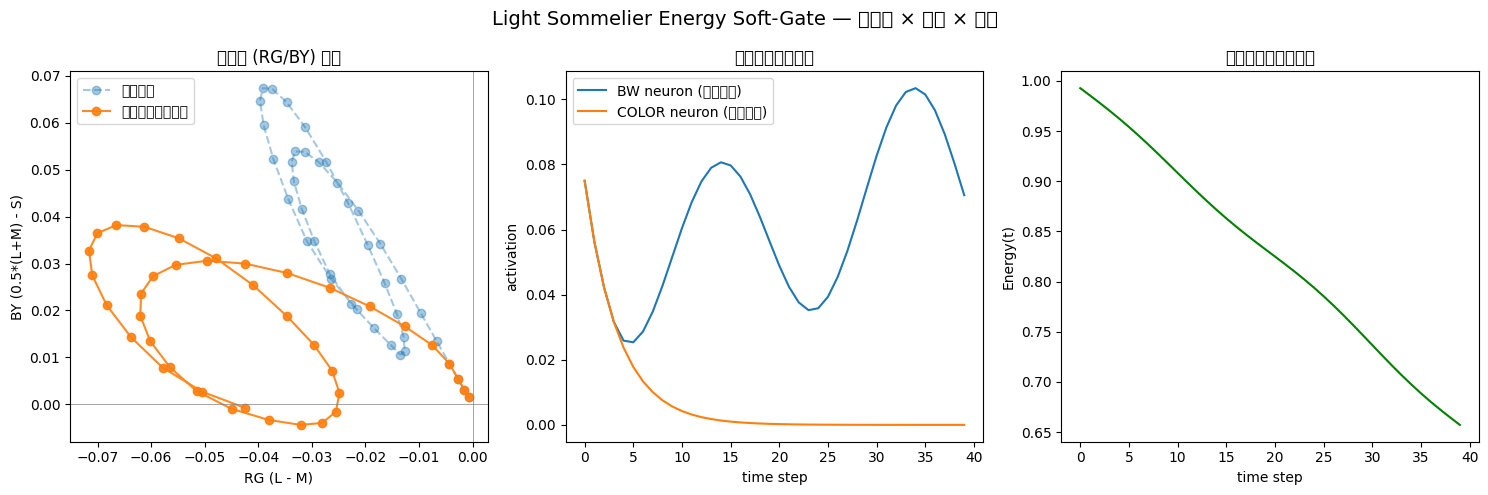


Block 8 OK — 试跑成功。
Soft-Gate termination step: None


In [22]:
# -------------------------------------------------------
# Block 8: 试跑示例（Clean Build）
# -------------------------------------------------------

# 取 batch 中第一条光谱作为示例输入
sample = stim_batch[0]['spectrum']

# 运行完整能态管线
RG, BY, RG_fb, BY_fb, BW, COLOR, Energy_ts, F_values, stop_t = run_energy_pipeline(
    sample,
    receptor_sens,
    wavelengths,
    T=len(phase_gate),   # 使用 block 6 推荐的相位门控长度
    gate=phase_gate
)

# 绘图
plot_energy_trajectory(
    RG, BY,
    RG_fb, BY_fb,
    BW, COLOR,
    Energy_ts,
    title="Light Sommelier Energy Soft-Gate — 中间态 × 决策 × 能态"
)

print("\nBlock 8 OK — 试跑成功。")
print(f"Soft-Gate termination step: {stop_t}")